In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pickle 
from obspy.clients.fdsn import Client

from grabmustang import geoStation

from noisemodels import accNLNM,accNHNM

In [ ]:
# Ely, Minnesota, USA
net = 'US'
sta = 'EYMN'
loc = ['**']
comp = ['BHZ']
label = 'Ely, Minnesota, USA'

# # Sawbill Land. Superior Nat. Forest USFS, MN, USA
# net = 'TA'
# sta = 'C38A'
# loc = ['**']
# comp = ['BHZ']
# label = 'Sawbill, Minnesota, USA'

# # Erie, Pennsylvania, USA
# net = 'US'
# sta = 'ERPA'
# loc = ['**']
# comp = ['BHZ']
# label = 'Erie, Pennsylvania, USA'

# # Sadowa, ON, CA
# net = 'CN'
# sta = 'SADO'
# loc = ['**']
# comp = ['BHZ']
# label = 'Sadowa, ON, CA'

# Average spectra to grab
tlist = [
        #  ['2007-02-15', '2007-03-09'], 
        #  ['2008-02-15', '2008-03-09'],
         ['2009-02-15', '2009-03-09'],
         ['2010-02-15', '2010-03-09'],
         ['2011-02-15', '2011-03-09'],
         ['2012-02-15', '2012-03-09'],
         ['2013-02-15', '2013-03-09'],
         ['2014-02-15', '2014-03-09'],
         ['2015-02-15', '2015-03-09'],
         ['2016-02-15', '2016-03-09'],
         ['2017-02-15', '2017-03-09'],
         ['2018-02-15', '2018-03-09'],
         ['2019-02-15', '2019-03-09'],
         ['2020-02-15', '2020-03-09'],
         ['2021-02-15', '2021-03-09'],
         ['2022-02-15', '2022-03-09'],
         ['2023-02-15', '2023-03-09'],
         ['2024-02-15', '2024-03-09'],
         ]

# # Average spectra to grab
# tlist = [
#         #  ['1995-02-15', '1995-03-09'], 
#         #  ['1996-02-15', '1996-03-09'],
#         #  ['1997-02-15', '1997-03-09'], 
#         #  ['1998-02-15', '1998-03-09'],
#         #  ['1999-02-15', '1999-03-09'], 
#          ['2000-02-15', '2000-03-09'],         
#          ['2001-02-15', '2001-03-09'], 
#          ['2002-02-15', '2002-03-09'],
#          ['2003-02-15', '2003-03-09'], 
#          ['2004-02-15', '2004-03-09'],
#          ['2005-02-15', '2005-03-09'], 
#          ['2006-02-15', '2006-03-09'],
#          ['2007-02-15', '2007-03-09'], 
#          ['2008-02-15', '2008-03-09'],
#          ['2009-02-15', '2009-03-09'],
#          ['2010-02-15', '2010-03-09'],
#          ['2011-02-15', '2011-03-09'],
#          ['2012-02-15', '2012-03-09'],
#          ['2013-02-15', '2013-03-09'],
#          ['2014-02-15', '2014-03-09'],
#          ['2015-02-15', '2015-03-09'],
#          ['2016-02-15', '2016-03-09'],
#          ['2017-02-15', '2017-03-09'],
#          ['2018-02-15', '2018-03-09'],
#          ['2019-02-15', '2019-03-09'],
#          ['2020-02-15', '2020-03-09'],
#         ['2021-02-15', '2021-03-09'],
#         ['2022-02-15', '2022-03-09'],
#         ['2023-02-15', '2023-03-09'],
#         ['2024-02-15', '2024-03-09'],
#         ]


# # For TA station in MN
# tlist = [
#          ['2011-02-15', '2011-03-09'],
#          ['2012-02-15', '2012-03-09'],
#          ]

In [3]:
STATION = geoStation(net,sta,loc,comp,label=label)
station_list = [STATION]

client = Client("IRIS")
inventory = client.get_stations(network=net, station=sta)

stalat = inventory[0][0].latitude
stalon = inventory[0][0].longitude

# # Grayling, MI
# US_GLMI = geoStation('US', 'GLMI', ['**'], ['BHZ'], label='Grayling, Michigan, USA')
# station_list = [US_GLMI]

# # Ely, Minnesota, USA
# US_EYMN = geoStation('US', 'EYMN', ['**'], ['BHZ'], label='Ely, Minnesota, USA')
# station_list = [US_EYMN]

# # Erie, Pennsylvania, USA
# US_ERPA = geoStation('US', 'ERPA', ['**'], ['BHZ'], label='Erie, Pennsylvania, USA')
# station_list = [US_ERPA]

# # Sadowa, ON, CA
# CN_SADO = geoStation('CN', 'SADO', ['**'], ['BHZ'], label='Sadowa, ON, CA')
# station_list = [CN_SADO]

# # West Carthage, New York
# TA_L38A = geoStation('TA', 'L38A', ['--'], ['BHZ'], label='West Carthage, New York')
# station_list = [TA_L38A]


In [ ]:
# Get seismic spectra

dof = 0
plotunit = 2

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 2 #1/0.65

# Get average noise properties
PSD_avg = 0
PSDs = []
PSD_band = []
PSD_band_std = []
years = []
start_dates = []
end_dates = []
icnt = 0
for station in station_list:
    for iyr in range(len(tlist)):
        
        start_date = pd.to_datetime(tlist[iyr][0],format='%Y-%m-%d')
        end_date = pd.to_datetime(tlist[iyr][1],format='%Y-%m-%d') 
          
        print(start_date.strftime('%Y-%m-%d')+' to '+end_date.strftime('%Y-%m-%d'))

        station.get_xml_histograms(tlist[iyr][0], tlist[iyr][1])
        station.get_text_percentiles(tlist[iyr][0], tlist[iyr][1])
        
        if len(station.text_percentiles[dof]) < 50:
            print('Missing '+tlist[iyr][0][0:4]+' trying HHZ component')
            station.channels = [c.replace('B','H') for c in station.channels]
            station.get_xml_histograms(tlist[iyr][0], tlist[iyr][1])
            station.get_text_percentiles(tlist[iyr][0], tlist[iyr][1])

            # Switch back to BHZ
            station.channels = comp

            if len(station.text_percentiles[dof]) < 50:
                print('skipping '+tlist[iyr][0][0:4])

                PSDs.append(np.nan*np.ones(freqs.shape))
                years.append(int(tlist[iyr][0][0:4]))
                PSD_band.append(np.nan)

                continue
            
            # Interpolate to same frequency axis
            station.text_percentiles[dof] = interp1d(station.freqs[dof],station.text_percentiles[dof])(freqs)


        else:
            # print('saving freqs')
            freqs = station.freqs[dof]

        
        PSD = 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*freqs)**(2-plotunit))

        PSDs.append(PSD)
        years.append(int(tlist[iyr][0][0:4]))
        start_dates.append(start_date)
        end_dates.append(end_date)

        PSD_band.append(np.mean(PSD[(freqs>=fmin) & (freqs<=fmax)]))
        PSD_band_std.append(np.std(PSD[(freqs>=fmin) & (freqs<=fmax)]))
        
        PSD_avg = PSD_avg + PSD
        icnt+=1


    PSD_avg = PSD_avg / icnt
    PSDs = np.asarray(PSDs)
    PSD_band = np.asarray(PSD_band)
    PSD_band_std = np.asarray(PSD_band_std)
    years = np.asarray(years)
    start_dates = np.asarray(start_dates)
    end_dates = np.asarray(end_dates)

    # Save pkl file of PSD spectrogram

    # Create a variable 
    data_PSDs = {'PSDs': PSDs, 'PSD_avg': PSD_avg, 'PSD_band': PSD_band, 'PSD_band_std': PSD_band_std, 'freqs': freqs, 'fmin': fmin, 'fmax': fmax, 'years': years, 'start_dates': start_dates, 'end_dates': end_dates, 'tlist': tlist, 'stalat': stalat, 'stalon': stalon,
                 'station': station.station, 'network':station.network, 'comp':station.channels[dof],
                 'label': station.label}

    filename = './PSDs/PSDavgstd_'+station.network+'_'+station.station+'_'+station.channels[dof]+'_'+str(years[0])+'-'+str(years[-1])+'_'+tlist[0][0][5:]+'_'+tlist[0][1][5:]+'_'+str(fmin)+'_'+str(fmax)+'Hz'+'.pkl'

    # Open a file and use dump() 
    with open(filename, 'wb') as file: 
        # A new file will be created 
        pickle.dump(data_PSDs, file)

2009-02-15 to 2009-03-09
2010-02-15 to 2010-03-09
2011-02-15 to 2011-03-09
2012-02-15 to 2012-03-09
2013-02-15 to 2013-03-09
2014-02-15 to 2014-03-09
2015-02-15 to 2015-03-09
2016-02-15 to 2016-03-09
2017-02-15 to 2017-03-09
2018-02-15 to 2018-03-09
2019-02-15 to 2019-03-09
2020-02-15 to 2020-03-09
Missing 2020 trying HHZ component
2021-02-15 to 2021-03-09
Missing 2021 trying HHZ component
2022-02-15 to 2022-03-09
Missing 2022 trying HHZ component
2023-02-15 to 2023-03-09
Missing 2023 trying HHZ component
2024-02-15 to 2024-03-09
Missing 2024 trying HHZ component


/var/folders/6v/_9qb6b3d3bv02mcvlzdc4q0h0000gn/T/ipykernel_51032/2272284285.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')


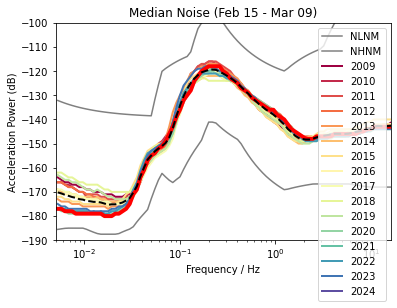

In [5]:
import matplotlib.cm as cm

plotunit = 2 # acceleration

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

ax.plot(freqs, 10*np.log10(accNLNM(freqs) / (2*np.pi*freqs)**(2-plotunit)),
              c='gray', label='NLNM')
ax.plot(freqs, 10*np.log10(accNHNM(freqs) / (2*np.pi*freqs)**(2-plotunit)),
            c='gray', label='NHNM')

for iyr in range(len(tlist)):

    ax.plot(freqs, PSDs[iyr],
            c=rgb[iyr], lw=2, linestyle='-', label=tlist[iyr][0][0:4])

ax.plot(freqs, PSDs[iyr],
              c='r', lw=4, linestyle='-')

ax.plot(freqs, PSD_avg,
              c='k', lw=2, linestyle='--')

ax.set_xscale('log')
ax.set_xlim([5e-3, 16])
ax.set_xlabel('Frequency / Hz')
ax.set_ylim([-190, -100])
ax.set_ylabel('Acceleration Power (dB)')
ax.set_title('Median Noise ('+start_dates[0].strftime('%b %d')+' - '+end_dates[0].strftime('%b %d')+')')
ax.legend()